In [18]:
from pulp import LpMaximize, LpProblem, LpVariable

m = LpProblem("Mezcla_Fertilizantes", LpMaximize)

x1 = LpVariable("F1_toneladas", lowBound=0, cat='Continuous')  # Toneladas de F1 producidas
x2 = LpVariable("F2_toneladas", lowBound=0, cat='Continuous')  # Toneladas de F2 producidas

m += 180*x1 + 220*x2  # Función objetivo: Maximizar Z = 180x1 + 220x2

m += 3*x1 + 4*x2 <= 120  # Restricción Compuesto A
m += 2*x1 + 1*x2 <= 80   # Restricción Compuesto B
m += 5*x1 + 3*x2 <= 150  # Restricción Compuesto C

m.solve()

print("GANANCIA MÁXIMA")
print(f"Fertilizante F1  = {x1.varValue:.2f} toneladas")
print(f"Fertilizante F2  = {x2.varValue:.2f} toneladas")
print(f"Ganancia máxima  = ${m.objective.value():.2f}")

Compuesto_A = 3*x1.varValue + 4*x2.varValue
Compuesto_B = 2*x1.varValue + 1*x2.varValue
Compuesto_C = 5*x1.varValue + 3*x2.varValue

print()
print("RECURSOS")
print(f"Compuesto A : {Compuesto_A:6.2f} kg - Máximo: 120 kg")
print(f"Compuesto B : {Compuesto_B:6.2f} kg - Máximo:  80 kg")
print(f"Compuesto C : {Compuesto_C:6.2f} kg - Máximo: 150 kg")

GANANCIA MÁXIMA
Fertilizante F1  = 21.82 toneladas
Fertilizante F2  = 13.64 toneladas
Ganancia máxima  = $6927.27

RECURSOS
Compuesto A : 120.00 kg - Máximo: 120 kg
Compuesto B :  57.27 kg - Máximo:  80 kg
Compuesto C : 150.00 kg - Máximo: 150 kg


In [25]:
import numpy as np

coeficientes = np.array([[0.4, -0.2],
                         [-0.1,  0.5]])  # Sistema de ecuaciones del punto de equilibrio
terminos_independientes = np.array([40, 20])  # Términos independientes del sistema

def produccion_siguiente(S_actual, M_actual):
    S_sig = 0.6 * S_actual + 0.2 * M_actual + 40  # S_n+1 = 0.6*S_n + 0.2*M_n + 40
    M_sig = 0.1 * S_actual + 0.5 * M_actual + 20  # M_n+1 = 0.1*S_n + 0.5*M_n + 20
    return S_sig, M_sig

S0 = 200  # Sillas iniciales (semana 0)
M0 = 80   # Mesas iniciales (semana 0)
n_simular = 17  # Número de semanas a simular

S = [S0]
M = [M0]

for i in range(n_simular):
    S_sig, M_sig = produccion_siguiente(S[i], M[i])  # Calcula la producción de la semana siguiente
    S.append(S_sig)
    M.append(M_sig)

print("EVOLUCIÓN DE PRODUCCIÓN SEMANAL")
print()

for i in range(len(S)):
    print(f"Semana {i}  Sillas = {S[i]:6.2f}    Mesas = {M[i]:6.2f}")

punto_de_equilibrio = np.linalg.solve(coeficientes, terminos_independientes)  # Resuelve el sistema para encontrar el punto de equilibrio

print()
print(f"Punto de equilibrio teórico: Sillas = {punto_de_equilibrio[0]:.2f}    Mesas = {punto_de_equilibrio[1]:.2f}")
print(f"Valores semana {n_simular}:          Sillas = {S[-1]:.2f}    Mesas = {M[-1]:.2f}")

EVOLUCIÓN DE PRODUCCIÓN SEMANAL

Semana 0  Sillas = 200.00    Mesas =  80.00
Semana 1  Sillas = 176.00    Mesas =  80.00
Semana 2  Sillas = 161.60    Mesas =  77.60
Semana 3  Sillas = 152.48    Mesas =  74.96
Semana 4  Sillas = 146.48    Mesas =  72.73
Semana 5  Sillas = 142.43    Mesas =  71.01
Semana 6  Sillas = 139.66    Mesas =  69.75
Semana 7  Sillas = 137.75    Mesas =  68.84
Semana 8  Sillas = 136.42    Mesas =  68.20
Semana 9  Sillas = 135.49    Mesas =  67.74
Semana 10  Sillas = 134.84    Mesas =  67.42
Semana 11  Sillas = 134.39    Mesas =  67.19
Semana 12  Sillas = 134.07    Mesas =  67.04
Semana 13  Sillas = 133.85    Mesas =  66.92
Semana 14  Sillas = 133.70    Mesas =  66.85
Semana 15  Sillas = 133.59    Mesas =  66.79
Semana 16  Sillas = 133.51    Mesas =  66.76
Semana 17  Sillas = 133.46    Mesas =  66.73

Punto de equilibrio teórico: Sillas = 133.33    Mesas = 66.67
Valores semana 17:          Sillas = 133.46    Mesas = 66.73


EPIDEMIA EN LA CIUDAD
Estado: Simulación exitosa
Infectados iniciales (t = 0): 50 personas
Infectados finales (t=300): I = 6665.49 personas
Equilibrio simulado: 6665.49 personas   (Teórico: 6666.67)


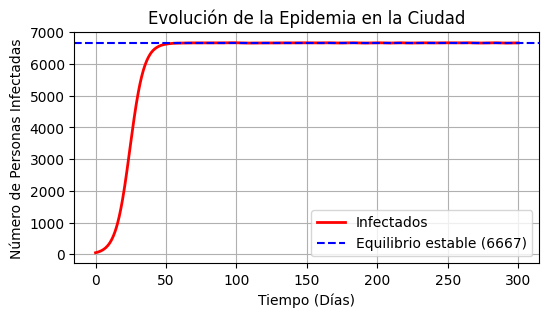

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

b = 0.00003   # Tasa de contagio por día
g = 0.1       # Tasa de recuperación por día
N = 10000     # Población total constante

def variacion_infectados(t, I):
    return b * (N - I) * I - g * I  # dI/dt = b*(N - I)*I - g*I

I0 = [50]                              # Condición inicial: 50 personas infectadas en t=0
intervalo_tiempo = (0, 300)            # Intervalo de simulación: de 0 a 300 días
dias_evaluacion = np.linspace(0, 300, 1000)

resultado = solve_ivp(
    variacion_infectados,
    intervalo_tiempo,
    I0,
    t_eval=dias_evaluacion,
    method='RK45'                      # Método numérico Runge-Kutta de orden 4/5
)

ultimo_dia = resultado.t[-1]
infectados_finales = resultado.y[0][-1]

print("EPIDEMIA EN LA CIUDAD")
print(f"Estado: {'Simulación exitosa' if resultado.success else 'Fallo'}")
print(f"Infectados iniciales (t = 0): {I0[0]} personas")
print(f"Infectados finales (t={int(ultimo_dia)}): I = {infectados_finales:.2f} personas")

equilibrio_teorico = N - (g/b)  # Punto de equilibrio endémico: dI/dt = 0 → I* = N - g/b
print(f"Equilibrio simulado: {infectados_finales:.2f} personas   (Teórico: {equilibrio_teorico:.2f})")

plt.figure(figsize=(6, 3))
plt.plot(resultado.t, resultado.y[0], label='Infectados', color='red', linewidth=2)
plt.axhline(y=equilibrio_teorico, color='blue', linestyle='--', label=f'Equilibrio estable ({equilibrio_teorico:.0f})')
plt.title('Evolución de la Epidemia en la Ciudad')
plt.xlabel('Tiempo (Días)')
plt.ylabel('Número de Personas Infectadas')
plt.grid(True)
plt.legend()
plt.show()

In [27]:
import numpy as np

H = 80        # Peces extraídos por año (pesca controlada)
K = 1000      # Capacidad máxima del lago
r = 0.4       # Tasa de crecimiento intrínseca

def siguiente_poblacion(P_actual):
    incremento = r * P_actual * (1 - P_actual / K)  # Crecimiento logístico: r*P*(1 - P/K)
    P_sig = P_actual + incremento - H               # Población siguiente = actual + crecimiento - pesca
    return P_sig

P0 = 400   # Población inicial
anos = 20  # Años a simular

registro_P = [P0]  # Historial de población año a año

for i in range(anos):
    P_sig = siguiente_poblacion(registro_P[i])  # Calcula la población del año siguiente
    registro_P.append(P_sig)

print("POBLACIÓN DE PECES EN EL LAGO")
print(f"Población Año 0: P0 = {registro_P[0]:.2f} peces")
print(f"Población Año 1: P1 = {registro_P[1]:.2f} peces")
print(f"Población Año 2: P2 = {registro_P[2]:.2f} peces")
print(f"Población al año {anos}: P = {registro_P[-1]:.2f} peces")

# Puntos de equilibrio: resuelve -r/K * P^2 + r*P - H = 0
factores = [-r/K, r, -H]
raices = np.roots(factores)  # Raíces de la ecuación cuadrática

punto_estable   = max(raices)  # Equilibrio estable: población sana sostenible
punto_inestable = min(raices)  # Equilibrio inestable: por debajo hay riesgo de extinción

print()
print("VERIFICACIÓN TEÓRICA")
print(f"Equilibrio estable   (población sana):    {punto_estable:.2f} peces")
print(f"Equilibrio inestable (riesgo extinción):  {punto_inestable:.2f} peces")

POBLACIÓN DE PECES EN EL LAGO
Población Año 0: P0 = 400.00 peces
Población Año 1: P1 = 416.00 peces
Población Año 2: P2 = 433.18 peces
Población al año 20: P = 696.12 peces

VERIFICACIÓN TEÓRICA
Equilibrio estable   (población sana):    723.61 peces
Equilibrio inestable (riesgo extinción):  276.39 peces
